In [104]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
from typing import Dict, Iterable, Tuple
import tempfile
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2


# Import ChromBERT utilities
import css_utility as crb

In [54]:
# essential data
LTR="../database/LTR/hg38_RepeatMasker_LTR.bed"

# Liver Cell Line (E066 from ROADMAP)
liver_cell = "../database/ROADMAP/hg38_mnemonics/unzipped/E066_15_coreMarks_hg38lift_mnemonics.bed"

# HepG2 Hepatocellular Carcinoma Cell Line (E118 from ROADMAP)
hepg2_cell = "../database/ROADMAP/hg38_mnemonics/unzipped/E118_15_coreMarks_hg38lift_mnemonics.bed"

# Gene annotation file (GENCODE v40)
gene_annotation = "../database/refGene.txt"

In [27]:
def make_ltr(inp="../database/LTR/hg38_RepeatMasker_LTR.bed",
                   out="./hg38_RepeatMasker_LTR_pm1kb.bed", dist=1000):
    
    # Read as 6-column BED
    df_ltr = pd.read_csv(
        inp,
        sep="\t",
        header=None,
        names=["chrom", "start", "end", "name", "score", "strand"],
        comment="#",
        engine="python"
    )

    # Keep only real BED rows
    df_ltr = df_ltr[df_ltr["chrom"].astype(str).str.startswith("chr")].copy()

    # Ensure numeric types
    df_ltr["start"] = pd.to_numeric(df_ltr["start"], errors="coerce")
    df_ltr["end"]   = pd.to_numeric(df_ltr["end"], errors="coerce")
    df_ltr = df_ltr.dropna(subset=["start", "end"])

    df_ltr["start"] = df_ltr["start"].astype(int)
    df_ltr["end"]   = df_ltr["end"].astype(int)

    # Expand ±1 kb
    df_ltr["start"] = (df_ltr["start"] - dist).clip(lower=0)
    df_ltr["end"]   = df_ltr["end"] + dist

    # Save BED
    df_ltr.to_csv(out, sep="\t", header=False, index=False)

    return df_ltr

In [34]:
df_ltr = make_ltr(
    inp=LTR,
    out="hg38_RepeatMasker_LTR_pm1kb.bed",
    dist=1000
)

In [35]:
df_ltr.head()

,chrom,start,end,name,score,strand
1,chr1,159382130,159385355,MSTA-int,6837.0,+
2,chr1,226491179,226493451,HUERS-P3b-int,2094.0,-
3,chr1,6290167,6292531,MLT1C,875.0,+
4,chr1,26213342,26215429,MLT1K,365.0,-
5,chr1,29358332,29361290,LTR5_Hs,8320.0,+


In [36]:
def make_ltr_df_on_celltype_from_mnemonics(
    mnemonics_bed,
    ltr_df,
    canonical_chroms=None,
    chrom_order=None,
    bin_size=200
):
    if canonical_chroms is None:
        canonical_chroms = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

    if chrom_order is None:
        chrom_order = {f"chr{i}": i for i in range(1, 23)}
        chrom_order.update({"chrX": 23, "chrY": 24})

    # 1. read original mnemonics BED
    df_raw = pd.read_csv(
        mnemonics_bed,
        sep="\t",
        header=None,
        names=["chromosome", "start", "end", "state"],
        usecols=[0, 1, 2, 3]
    )

    # 2. keep canonical chromosomes
    df_raw = df_raw[df_raw["chromosome"].isin(canonical_chroms)].copy()

    # 3. numeric cleanup
    df_raw["start"] = pd.to_numeric(df_raw["start"], errors="coerce")
    df_raw["end"] = pd.to_numeric(df_raw["end"], errors="coerce")
    df_raw = df_raw.dropna(subset=["start", "end"]).copy()
    df_raw["start"] = df_raw["start"].astype(int)
    df_raw["end"] = df_raw["end"].astype(int)

    # 4. sort in Python
    df_raw["chrom_order"] = df_raw["chromosome"].map(chrom_order)
    df_raw = (
        df_raw
        .sort_values(["chrom_order", "start", "end"])
        .drop(columns="chrom_order")
        .reset_index(drop=True)
    )

    # 5. convert mnemonic -> state number only
    #    e.g. 15_Quies -> 15
    df_raw["state"] = df_raw["state"].astype(str).str.replace(r"_.*", "", regex=True)

    # 6. write temporary stateno BED for crb.bed2df_expanded()
    with tempfile.NamedTemporaryFile(mode="w", suffix=".stateno.bed", delete=False) as tmp:
        tmp_path = tmp.name
        df_raw.to_csv(tmp_path, sep="\t", header=False, index=False)

    try:
        # 7. use YOUR function here
        df_state = crb.bed2df_expanded(tmp_path)

    finally:
        if os.path.exists(tmp_path):
            os.remove(tmp_path)

    # 8. keep canonical chromosomes and sort
    df_state = (
        df_state[df_state["chromosome"].isin(canonical_chroms)]
        .assign(chrom_order=lambda x: x["chromosome"].map(chrom_order))
        .sort_values(["chrom_order", "start", "end"])
        .drop(columns="chrom_order")
        .reset_index(drop=True)
    )

    # 9. build chromosome-wide state strings from state_seq_full
    chr_seq_map = (
        df_state.groupby("chromosome", sort=False)["state_seq_full"]
        .apply("".join)
        .to_dict()
    )

    # 10. slice onto LTR windows
    def slice_chr_seq(chrom, start_bp, end_bp):
        seq = chr_seq_map.get(chrom)
        if seq is None:
            return None

        bin_start = start_bp // bin_size
        bin_end = (end_bp - 1) // bin_size + 1
        return seq[bin_start:bin_end]

    df_ltr_on_cell = ltr_df.copy()
    df_ltr_on_cell = df_ltr_on_cell[df_ltr_on_cell["chrom"].isin(canonical_chroms)].copy()

    df_ltr_on_cell["length"] = df_ltr_on_cell["end"] - df_ltr_on_cell["start"]

    df_ltr_on_cell["state_seq_full_slice"] = df_ltr_on_cell.apply(
        lambda r: slice_chr_seq(r["chrom"], int(r["start"]), int(r["end"])),
        axis=1
    )

    df_ltr_on_cell["n_bins"] = df_ltr_on_cell["state_seq_full_slice"].str.len()

    df_ltr_on_cell["chrom_order"] = df_ltr_on_cell["chrom"].map(chrom_order)

    df_ltr_on_cell = (
        df_ltr_on_cell
        .sort_values(["chrom_order", "start", "end"])
        .drop(columns="chrom_order")
        .reset_index(drop=True)
    )

    df_ltr_on_cell = df_ltr_on_cell[df_ltr_on_cell["n_bins"] > 0]

    return df_ltr_on_cell

In [37]:
df_ltr_E066 = make_ltr_df_on_celltype_from_mnemonics(
    liver_cell,
    df_ltr
)

In [38]:
df_ltr_E066

,chrom,start,end,name,score,strand,length,state_seq_full_slice,n_bins
0,chr1,20948,23075,MLT1K,254.0,+,2127,OOOOOOOOOOOO,12
1,chr1,29693,31848,MLT1A,741.0,+,2155,OOOOOOOOOOOO,12
2,chr1,29952,32131,MLT1A,741.0,+,2179,OOOOOOOOOOOO,12
3,chr1,33564,35921,MLT1J2,850.0,-,2357,OOOOOOOOOOOOO,13
4,chr1,37255,40464,MLT1E1A-int,3877.0,+,3209,OOOOOOOOOOOOOOOOO,17
...,...,...,...,...,...,...,...,...,...
719759,chrY,25239006,25241335,MER66-int,1531.0,+,2329,IIIIIIIIIIII,12
719760,chrY,25239335,25241651,MER66B,1077.0,+,2316,IIIIIIIIIIIII,13
719761,chrY,25239698,25242327,LTR12D,3938.0,-,2629,IIIIIIIIIIIIII,14
719762,chrY,25240331,25242491,LTR12D,909.0,-,2160,IIIIIIIIIIII,12


In [39]:
df_ltr_E118 = make_ltr_df_on_celltype_from_mnemonics(
    hepg2_cell,
    df_ltr
)
df_ltr_E118

,chrom,start,end,name,score,strand,length,state_seq_full_slice,n_bins
0,chr1,20948,23075,MLT1K,254.0,+,2127,OOOOOOOOOOOO,12
1,chr1,29693,31848,MLT1A,741.0,+,2155,OOOOOOOOOOOO,12
2,chr1,29952,32131,MLT1A,741.0,+,2179,OOOOOOOOOOOO,12
3,chr1,33564,35921,MLT1J2,850.0,-,2357,OOOOOOOOOOOOO,13
4,chr1,37255,40464,MLT1E1A-int,3877.0,+,3209,OOOOOOOOOOOOOOOOO,17
...,...,...,...,...,...,...,...,...,...
719759,chrY,25239006,25241335,MER66-int,1531.0,+,2329,IIIIIIIIIIII,12
719760,chrY,25239335,25241651,MER66B,1077.0,+,2316,IIIIIIIIIIIII,13
719761,chrY,25239698,25242327,LTR12D,3938.0,-,2629,IIIIIIIIIIIIII,14
719762,chrY,25240331,25242491,LTR12D,909.0,-,2160,IIIIIIIIIIII,12


In [40]:
def make_ltr_transition_df(
    df_ltr_on_cell,
    remove_all_O=True,
    min_length_bp=1
):
    """
    Build an analysis-ready LTR transition dataframe from a sliced LTR dataframe.

    Parameters
    ----------
    df_ltr_on_cell : pd.DataFrame
        Output of make_ltr_df_on_celltype_from_mnemonics(), expected to contain:
        chrom, start, end, name, score, strand, length, state_seq_full_slice, n_bins

    remove_all_O : bool, default True
        If True, remove rows whose state_seq_full_slice contains only 'O'.

    min_length_bp : int, default 1
        Minimum length required to compute transition density.

    Returns
    -------
    df_ltr_trans : pd.DataFrame
        Dataframe with additional columns:
        state_comp, n_states, n_transitions, transition_density_per_kb
    """

    df_ltr_trans = df_ltr_on_cell.copy()

    # state composition
    df_ltr_trans["state_comp"] = df_ltr_trans["state_seq_full_slice"].apply(
        lambda s: Counter(s) if isinstance(s, str) else {}
    )

    # optionally remove all-O rows
    if remove_all_O:
        df_ltr_trans = df_ltr_trans[
            df_ltr_trans["state_comp"].apply(lambda c: any(k != "O" for k in c))
        ].copy()

    # distinct number of states
    df_ltr_trans["n_states"] = df_ltr_trans["state_comp"].apply(len)

    # transition count
    def count_transitions(seq):
        if not isinstance(seq, str) or len(seq) == 0:
            return 0
        return sum(seq[i] != seq[i - 1] for i in range(1, len(seq)))

    df_ltr_trans["n_transitions"] = df_ltr_trans["state_seq_full_slice"].apply(count_transitions)

    # transition density per kb
    df_ltr_trans = df_ltr_trans[df_ltr_trans["length"] >= min_length_bp].copy()
    df_ltr_trans["transition_density_per_kb"] = (
        df_ltr_trans["n_transitions"] / (df_ltr_trans["length"] / 1000)
    )

    return df_ltr_trans

In [53]:
df_ltr_trans_E066=make_ltr_transition_df(df_ltr_E066)
df_sorted_E066 = df_ltr_trans_E066.sort_values("transition_density_per_kb", ascending=False)
df_sorted_E066.head(10)

,chrom,start,end,name,score,strand,length,state_seq_full_slice,n_bins,state_comp,n_states,n_transitions,transition_density_per_kb
590929,chr17,30658947,30660993,MLT1G1,409.0,-,2046,GBGGBABAAGO,11,"{'G': 4, 'B': 3, 'A': 3, 'O': 1}",4,8,3.910068
267644,chr6,28753325,28755377,THE1D,1946.0,-,2052,NGBABABBBGE,11,"{'N': 1, 'G': 2, 'B': 5, 'A': 2, 'E': 1}",5,8,3.898635
599789,chr17,76862366,76864714,MLT1C,1106.0,+,2348,GGBBBABABABGE,13,"{'G': 3, 'B': 6, 'A': 3, 'E': 1}",4,9,3.833049
12372,chr1,55820554,55822919,MER57B1,2346.0,+,2365,BGGBGBGGBGBGG,13,"{'B': 5, 'G': 8}",2,9,3.805497
77711,chr2,106416312,106418341,MLT2A1,2529.0,+,2029,GBBAABABGOO,11,"{'G': 2, 'B': 4, 'A': 3, 'O': 2}",4,7,3.449975
565496,chr16,2870987,2873323,MLT2F,440.0,-,2336,EEBAABBABAABG,13,"{'E': 2, 'B': 5, 'A': 5, 'G': 1}",4,8,3.424658
598733,chr17,72047939,72050298,MLT1A0,2011.0,+,2359,GGBBGEEABABAA,13,"{'G': 3, 'B': 4, 'E': 2, 'A': 4}",4,8,3.391267
26012,chr1,108607742,108610101,MLT1A0,1607.0,-,2359,BABABBGBGGEEE,13,"{'B': 5, 'A': 2, 'G': 3, 'E': 3}",4,8,3.391267
107198,chr2,226142758,226144825,MLT2A1,412.0,-,2067,BBGGBGBGGBGG,12,"{'B': 5, 'G': 7}",2,7,3.386551
77710,chr2,106415909,106418273,MLT2A1,2529.0,+,2364,OOGBBAABABGOO,13,"{'O': 4, 'G': 2, 'B': 4, 'A': 3}",4,8,3.384095


In [52]:
df_ltr_trans_E118=make_ltr_transition_df(df_ltr_E118)
df_sorted_E118 = df_ltr_trans_E118.sort_values("transition_density_per_kb", ascending=False)
df_sorted_E118.head(10)

,chrom,start,end,name,score,strand,length,state_seq_full_slice,n_bins,state_comp,n_states,n_transitions,transition_density_per_kb
477451,chr12,54446160,54448203,LTR67B,684.0,+,2043,LJKLKLKLKKLL,12,"{'L': 6, 'J': 1, 'K': 5}",3,9,4.405286
477450,chr12,54445905,54448018,LTR67B,455.0,+,2113,LLJKLKLKLKKL,12,"{'L': 6, 'J': 1, 'K': 5}",3,9,4.259347
378213,chr9,6705758,6707836,MER70B,2171.0,+,2078,BKJJJKKBGBGO,12,"{'B': 3, 'K': 3, 'J': 3, 'G': 2, 'O': 1}",5,8,3.849856
293760,chr6,140512760,140515106,MLT1A0,1640.0,+,2346,GBGBBKJJJAKBG,13,"{'G': 3, 'B': 4, 'K': 2, 'J': 3, 'A': 1}",5,9,3.836317
568764,chr16,14814855,14817028,LTR40a,1681.0,-,2173,EGBGEAEEEAEE,12,"{'E': 7, 'G': 2, 'B': 1, 'A': 2}",4,8,3.681546
332946,chr7,135863400,135865617,MSTD,1739.0,-,2217,BABABBABBAAB,12,"{'B': 7, 'A': 5}",2,8,3.608480
78341,chr2,108412796,108415025,MLT1J1,408.0,+,2229,LMMMMJLKLKLLN,13,"{'L': 5, 'M': 4, 'J': 1, 'K': 2, 'N': 1}",5,8,3.589053
589213,chr17,17468929,17471175,MSTB,1940.0,-,2246,GBGGBLKLGGGL,12,"{'G': 6, 'B': 2, 'L': 3, 'K': 1}",4,8,3.561888
619881,chr19,1385246,1387499,MLT1B,1510.0,-,2253,ABBAAAJKJKJM,12,"{'A': 4, 'B': 2, 'J': 3, 'K': 2, 'M': 1}",5,8,3.550821
259118,chr5,177028755,177031066,MER21B,1924.0,+,2311,BGBGGGLLKKBGE,13,"{'B': 3, 'G': 5, 'L': 2, 'K': 2, 'E': 1}",5,8,3.461705


In [65]:
def load_refgene_full(gene_annotation):
    gene_df = pd.read_csv(
        gene_annotation,
        sep="\t",
        header=None,
        names=[
            "bin","name","chrom","strand",
            "txStart","txEnd",
            "cdsStart","cdsEnd",
            "exonCount","exonStarts","exonEnds",
            "score","name2","cdsStartStat","cdsEndStat","exonFrames"
        ]
    )

    # cleanup
    gene_df["txStart"] = pd.to_numeric(gene_df["txStart"], errors="coerce")
    gene_df["txEnd"] = pd.to_numeric(gene_df["txEnd"], errors="coerce")
    gene_df = gene_df.dropna(subset=["txStart","txEnd"]).copy()

    gene_df["txStart"] = gene_df["txStart"].astype(int)
    gene_df["txEnd"] = gene_df["txEnd"].astype(int)

    # add TSS
    gene_df["tss"] = np.where(
        gene_df["strand"] == "+",
        gene_df["txStart"],
        gene_df["txEnd"]
    )

    gene_df["gene_name"] = gene_df["name2"]

    return gene_df

In [67]:
gene_df=load_refgene_full(
    gene_annotation,
)
gene_df

,bin,name,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds,score,name2,cdsStartStat,cdsEndStat,exonFrames,tss,gene_name
0,585,NR_024540,chr1,-,14361,29370,29370,29370,11,"14361,14969,15795,16606,16857,17232,17605,1791...","14829,15038,15947,16765,17055,17368,17742,1806...",0,WASH7P,unk,unk,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,",29370,WASH7P
1,585,NR_106918,chr1,-,17368,17436,17436,17436,1,"17368,","17436,",0,MIR6859-1,unk,unk,"-1,",17436,MIR6859-1
2,585,NR_107062,chr1,-,17368,17436,17436,17436,1,"17368,","17436,",0,MIR6859-2,unk,unk,"-1,",17436,MIR6859-2
3,585,NR_107063,chr1,-,17368,17436,17436,17436,1,"17368,","17436,",0,MIR6859-3,unk,unk,"-1,",17436,MIR6859-3
4,585,NR_128720,chr1,-,17368,17436,17436,17436,1,"17368,","17436,",0,MIR6859-4,unk,unk,"-1,",17436,MIR6859-4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88814,1306,NM_001385728,chr5,-,94519215,94618604,94520242,94537126,6,"94519215,94523929,94536995,94558677,94611820,9...","94520917,94524098,94537127,94558834,94611937,9...",0,KIAA0825,cmpl,cmpl,"0,2,0,-1,-1,-1,",94618604,KIAA0825
88815,1306,NM_001385729,chr5,-,94519215,94618604,94520242,94537126,6,"94519215,94523929,94536995,94551321,94582432,9...","94520917,94524098,94537127,94551451,94582583,9...",0,KIAA0825,cmpl,cmpl,"0,2,0,-1,-1,-1,",94618604,KIAA0825
88816,1306,NR_169752,chr5,-,94519215,94618604,94618604,94618604,4,"94519215,94536995,94582432,94618499,","94520917,94537127,94582583,94618604,",0,KIAA0825,unk,unk,"-1,-1,-1,-1,",94618604,KIAA0825
88817,1306,NR_169753,chr5,-,94519215,94618604,94618604,94618604,6,"94519215,94523929,94530145,94536995,94582432,9...","94520917,94524098,94530243,94537127,94582583,9...",0,KIAA0825,unk,unk,"-1,-1,-1,-1,-1,-1,",94618604,KIAA0825


In [68]:
def annotate_hotspots_with_nearest_tss(
    df_ltr_trans,
    gene_df,
    mode="n_transitions",
    threshold=4,
    gene_name_col="gene_name"
):
    """
    Annotate hotspot LTRs with nearest gene TSS.

    Parameters
    ----------
    df_ltr_trans : pd.DataFrame
        LTR transition dataframe, expected to contain:
        chrom, start, end, name, length, n_states, n_transitions,
        transition_density_per_kb, state_seq_full_slice

    gene_df : pd.DataFrame
        Gene annotation dataframe, expected to contain:
        chrom, strand, tss, and gene_name_col

    mode : str
        "n_transitions" or "transition_density_per_kb"

    threshold : float
        Threshold for defining hotspots.
        Example:
            mode="n_transitions", threshold=4
            mode="transition_density_per_kb", threshold=2.0

    gene_name_col : str
        Column in gene_df containing gene symbols/names.

    Returns
    -------
    hotspot_annot : pd.DataFrame
        Hotspot dataframe annotated with nearest gene and TSS distance.
    """

    if mode not in ["n_transitions", "transition_density_per_kb"]:
        raise ValueError("mode must be 'n_transitions' or 'transition_density_per_kb'")

    # 1. define hotspots
    if mode == "n_transitions":
        hotspot_annot = df_ltr_trans[df_ltr_trans["n_transitions"] >= threshold].copy()
    else:
        hotspot_annot = df_ltr_trans[df_ltr_trans["transition_density_per_kb"] >= threshold].copy()

    # 2. keep only needed gene columns
    gene_use = gene_df[["chrom", "strand", "tss", gene_name_col]].copy()
    gene_use = gene_use.dropna(subset=["chrom", "tss"]).copy()
    gene_use["tss"] = pd.to_numeric(gene_use["tss"], errors="coerce")
    gene_use = gene_use.dropna(subset=["tss"]).copy()
    gene_use["tss"] = gene_use["tss"].astype(int)

    # 3. pre-split genes by chromosome for speed
    gene_by_chr = {}
    for chrom, sub in gene_use.groupby("chrom"):
        sub = sub.sort_values("tss").reset_index(drop=True)
        gene_by_chr[chrom] = sub

    # 4. nearest TSS helper
    def find_nearest_tss(chrom, start, end):
        if chrom not in gene_by_chr:
            return pd.Series({
                "nearest_gene": None,
                "nearest_gene_strand": None,
                "nearest_tss": np.nan,
                "tss_distance": np.nan
            })

        sub = gene_by_chr[chrom]
        tss_array = sub["tss"].values

        # distance from interval to TSS:
        # 0 if TSS inside [start, end]
        # otherwise min distance to interval edges
        dist = np.where(
            tss_array < start,
            start - tss_array,
            np.where(tss_array > end, tss_array - end, 0)
        )

        idx = dist.argmin()

        return pd.Series({
            "nearest_gene": sub.iloc[idx][gene_name_col],
            "nearest_gene_strand": sub.iloc[idx]["strand"],
            "nearest_tss": sub.iloc[idx]["tss"],
            "tss_distance": int(dist[idx])
        })

    # 5. annotate hotspots
    annot_df = hotspot_annot.apply(
        lambda r: find_nearest_tss(r["chrom"], int(r["start"]), int(r["end"])),
        axis=1
    )

    hotspot_annot = pd.concat([hotspot_annot.reset_index(drop=True),
                               annot_df.reset_index(drop=True)], axis=1)

    return hotspot_annot

In [72]:
hotspot_annot_E066=annotate_hotspots_with_nearest_tss(
    df_ltr_trans_E066,
    gene_df,
    mode="n_transitions",
    threshold=4,
    gene_name_col="gene_name"
)
hotspot_annot_E066

,chrom,start,end,name,score,strand,length,state_seq_full_slice,n_bins,state_comp,n_states,n_transitions,transition_density_per_kb,nearest_gene,nearest_gene_strand,nearest_tss,tss_distance
0,chr1,697202,699441,MLT1H1,1163.0,+,2239,GGGGBGBGGGBN,12,"{'G': 8, 'B': 3, 'N': 1}",3,6,2.679768,OR4F29,-,686654,10548
1,chr1,697441,699799,THE1B,1805.0,-,2358,GGGBGBGGGBNN,12,"{'G': 7, 'B': 3, 'N': 2}",3,6,2.544529,OR4F29,-,686654,10787
2,chr1,697799,701363,THE1B-int,11013.0,-,3564,GGBGBGGGBNNMNNNNNNN,19,"{'G': 6, 'B': 3, 'N': 9, 'M': 1}",4,8,2.244669,OR4F29,-,686654,11145
3,chr1,732909,735062,LTR41,678.0,-,2153,BBGGGAAAABGE,12,"{'B': 3, 'G': 4, 'A': 4, 'E': 1}",4,5,2.322341,LOC100288069,-,778634,43572
4,chr1,887956,890347,MSTD,2441.0,+,2391,EEGBGGEAAAABB,13,"{'E': 3, 'G': 3, 'B': 3, 'A': 4}",4,6,2.509410,FAM41C,-,876802,11154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7825,chrX,149215310,149218796,THE1B-int,9415.0,+,3486,EEEEEEEEEGGGEEEEGE,18,"{'E': 14, 'G': 4}",2,4,1.147447,IDS,-,149505306,286510
7826,chrX,149216795,149219088,THE1B,1832.0,+,2293,EEGGGEEEEGEEG,13,"{'E': 8, 'G': 5}",2,5,2.180549,IDS,-,149505306,286218
7827,chrX,149217089,149219618,MLT2B1,1391.0,+,2529,GGGEEEEGEEGGGG,14,"{'G': 8, 'E': 6}",2,4,1.581653,IDS,-,149505306,285688
7828,chrX,149412806,149415054,MSTB,2226.0,+,2248,OOOGGGBGGBBG,12,"{'O': 3, 'G': 6, 'B': 3}",3,5,2.224199,IDS,-,149505306,90252


In [80]:
hotspot_annot_E118=annotate_hotspots_with_nearest_tss(
    df_ltr_trans_E118,
    gene_df,
    mode="n_transitions",
    threshold=4,
    gene_name_col="gene_name"
)
hotspot_annot_E118

,chrom,start,end,name,score,strand,length,state_seq_full_slice,n_bins,state_comp,n_states,n_transitions,transition_density_per_kb,nearest_gene,nearest_gene_strand,nearest_tss,tss_distance
0,chr1,642989,645147,MLT1I,658.0,+,2158,NLLKLMMMNNNN,12,"{'N': 5, 'L': 3, 'K': 1, 'M': 3}",4,5,2.316960,MIR12136,-,632685,10304
1,chr1,643210,645273,MLT1I,320.0,+,2063,LKLMMMNNNNN,11,"{'L': 2, 'K': 1, 'M': 3, 'N': 5}",4,4,1.938924,MIR12136,-,632685,10525
2,chr1,697202,699441,MLT1H1,1163.0,+,2239,AAAAKKJJJJKL,12,"{'A': 4, 'K': 3, 'J': 4, 'L': 1}",4,4,1.786512,OR4F29,-,686654,10548
3,chr1,697441,699799,THE1B,1805.0,-,2358,AAAKKJJJJKLM,12,"{'A': 3, 'K': 3, 'J': 4, 'L': 1, 'M': 1}",5,5,2.120441,OR4F29,-,686654,10787
4,chr1,697799,701363,THE1B-int,11013.0,-,3564,AAKKJJJJKLMMMMMMMMM,19,"{'A': 2, 'K': 3, 'J': 4, 'L': 1, 'M': 9}",5,5,1.402918,OR4F29,-,686654,11145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12007,chrY,14625095,14627915,LTR12C,5949.0,-,2820,OEEEEEGGGGGGBBG,15,"{'O': 1, 'E': 5, 'G': 7, 'B': 2}",4,4,1.418440,NLGN4Y,+,14622020,3075
12008,chrY,14831660,14834583,MER11C,7171.0,-,2923,OIIOOIIOOOOOOOO,15,"{'O': 11, 'I': 4}",2,4,1.368457,NLGN4Y-AS1,-,14804033,27627
12009,chrY,19655545,19659902,HERVK9-int,17929.0,-,4357,IIIIIIOOOOOOOOIIOOOOOII,23,"{'I': 10, 'O': 13}",2,4,0.918063,KDM5D,-,19744726,84824
12010,chrY,20093981,20208783,LTR12B,1855.0,-,114802,OOOOOOOIIIIIIIIOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOO...,575,"{'O': 455, 'I': 120}",2,16,0.139370,TTTY10,-,20519228,310445


In [ ]:
print((hotspot_annot_E066["tss_distance"] == 0).mean())
print(<(hotspot_annot_E066["tss_distance"] <= 1000).mean())
print((hotspot_annot_E066["tss_distance"] <= 5000).mean())
print((hotspot_annot_E066["tss_distance"] <= 10000).mean())

0.013665389527458494
0.03243933588761175
0.10574712643678161
0.20945083014048532


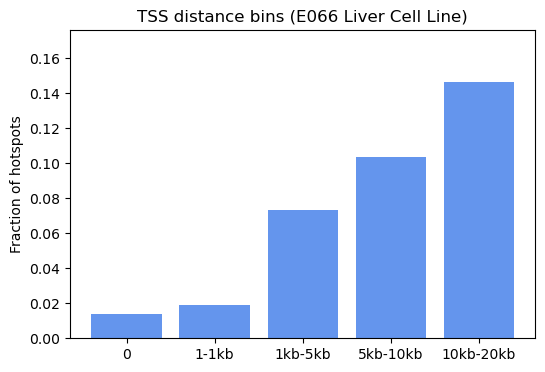

In [88]:
bins = [
    (0, 0),
    (1, 1000),
    (1001, 5000),
    (5001, 10000),
    (10001, 20000)
]
dist = hotspot_annot_E066["tss_distance"].values
labels = ["0", "1-1kb", "1kb-5kb", "5kb-10kb", "10kb-20kb"]

fractions = [
    ((dist >= low) & (dist <= high)).mean()
    for (low, high) in bins
]

plt.figure(figsize=(6,4))

plt.bar(labels, fractions, color="cornflowerblue")

plt.ylabel("Fraction of hotspots")
plt.title("TSS distance bins (E066 Liver Cell Line)")
plt.ylim(0, max(fractions)*1.2)

plt.show()

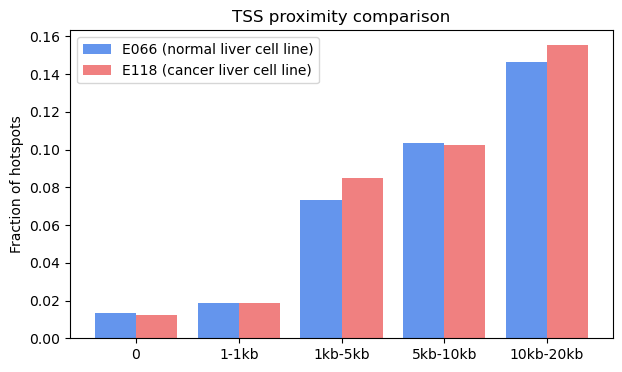

In [89]:
def compute_bin_fraction(dist, bins):
    return [((dist >= low) & (dist <= high)).mean() for (low, high) in bins]

dist_A = hotspot_annot_E066["tss_distance"].values
dist_B = hotspot_annot_E118["tss_distance"].values

bins = [
    (0, 0),
    (1, 1000),
    (1001, 5000),
    (5001, 10000),
    (10001, 20000)
]

labels = ["0", "1-1kb", "1kb-5kb", "5kb-10kb", "10kb-20kb"]

frac_A = compute_bin_fraction(dist_A, bins)
frac_B = compute_bin_fraction(dist_B, bins)

x = np.arange(len(labels))

plt.figure(figsize=(7,4))

plt.bar(x - 0.2, frac_A, width=0.4, label="E066 (normal liver cell line)", color="cornflowerblue")
plt.bar(x + 0.2, frac_B, width=0.4, label="E118 (cancer liver cell line)", color="lightcoral")

plt.xticks(x, labels)
plt.ylabel("Fraction of hotspots")
plt.title("TSS proximity comparison")
plt.legend()

plt.show()

In [90]:
def extract_hotspot_nearby_genes(
    hotspot_annot,
    max_tss_distance=5000,
    gene_col="nearest_gene",
    return_df=False
):
    """
    Extract genes near hotspot LTRs within a given TSS distance.

    Parameters
    ----------
    hotspot_annot : pd.DataFrame
        Output of annotate_hotspots_with_nearest_tss()

    max_tss_distance : int, default 5000
        Maximum allowed distance to nearest TSS

    gene_col : str, default "nearest_gene"
        Column containing gene names

    return_df : bool, default False
        If True, also return the filtered dataframe

    Returns
    -------
    genes : list
        Unique nearby genes

    filtered_df : pd.DataFrame, optional
        Filtered hotspot dataframe
    """

    filtered_df = hotspot_annot[
        hotspot_annot["tss_distance"].notna() &
        (hotspot_annot["tss_distance"] <= max_tss_distance)
    ].copy()

    genes = (
        filtered_df[gene_col]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    if return_df:
        return genes, filtered_df
    return genes

In [91]:
genes_E066_5kb, hotspot_E066_5kb = extract_hotspot_nearby_genes(
    hotspot_annot_E066,
    max_tss_distance=5000,
    return_df=True
)

In [94]:
len(genes_E066_5kb)

541

In [96]:
genes_E118_5kb, hotspot_E118_5kb = extract_hotspot_nearby_genes(
    hotspot_annot_E118,
    max_tss_distance=5000,
    return_df=True
)

In [97]:
len(genes_E118_5kb)

848

In [98]:
hotspot_E118_5kb[[
    "chrom", "start", "end", "name",
    "nearest_gene", "tss_distance"
]].head(20)

,chrom,start,end,name,nearest_gene,tss_distance
18,chr1,1002499,1004623,MLT1G1,HES4,2402
20,chr1,1134294,1136888,MER41B,LINC01342,128
21,chr1,1172026,1174396,LTR46,TTLL10,0
23,chr1,1277792,1280090,MER4B-int,SCNN1D,345
24,chr1,1278193,1280400,MER4B-int,SCNN1D,35
25,chr1,1445921,1448108,LTR10A,ATAD3C,1580
26,chr1,1446706,1448837,HERV9N-int,ATAD3C,851
27,chr1,1447138,1449272,HERV9N-int,ATAD3C,416
28,chr1,1447592,1449681,HERV9N-int,ATAD3C,7
29,chr1,1689939,1692361,MLT1F2,SLC35E2B,434


In [ ]:
print(len(set(genes_E066_5kb) & set(genes_E118_5kb)))
print(len(set(genes_E118_5kb) - set(genes_E066_5kb)))
print(len(set(genes_E066_5kb) - set(genes_E118_5kb)))

195
653
346


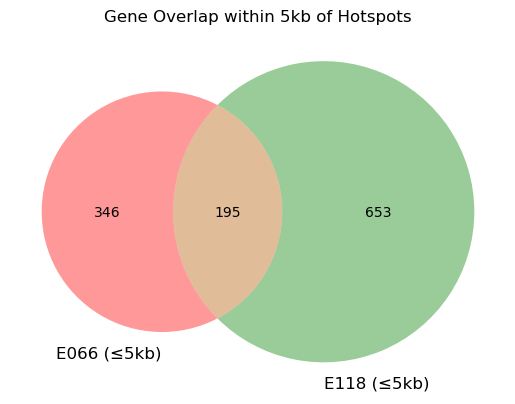

In [105]:
# Values
only_E066 = len(set(genes_E066_5kb) - set(genes_E118_5kb))
only_E118 = len(set(genes_E118_5kb) - set(genes_E066_5kb))
both = len(set(genes_E066_5kb) & set(genes_E118_5kb))

# Plot
plt.figure()
venn2(subsets=(only_E066, only_E118, both),
      set_labels=('E066 (≤5kb)', 'E118 (≤5kb)'))

plt.title('Gene Overlap within 5kb of Hotspots')
plt.show()